In [140]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy.polynomial.polynomial as poly
from numpy.polynomial import Polynomial
import scipy.constants as const
from astropy.time import Time

In [141]:
#Datos de Betelguese, Antares y Ras Algethi 
ruta_datos_Smith = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos de fuentes externas\Smith.xlsx"

datos_betelgeuse = pd.read_excel(
    ruta_datos_Smith, 
    usecols=[1, 2, 3],      # Ajusta según las columnas reales en tu Excel
    skiprows=2              # Ajusta según la fila donde comiencen los subtítulos reales
)

datos_antares = pd.read_excel(
    ruta_datos_Smith, 
    usecols=[5, 6, 7],      # Ajusta según las columnas reales en tu Excel
    skiprows=2              # Ajusta según la fila donde comiencen los subtítulos reales
)

datos_antares = datos_antares.dropna()

datos_rasalgethi = pd.read_excel(
    ruta_datos_Smith, 
    usecols=[9, 10, 11],     # Ajusta según las columnas reales en tu Excel
    skiprows=2              # Ajusta según la fila donde comiencen los subtítulos reales
)

datos_rasalgethi = datos_rasalgethi.dropna()

print("--- BETELGEUSE ---")
display(datos_betelgeuse.head())


print("--- ANTARES ---")
display(datos_antares.head())


print("--- RAS ALGETHI ---")
display(datos_rasalgethi.head())

--- BETELGEUSE ---


,Día Juliano,Líneas Metálicas,H_alpha
0,5982,22.81,-6.01
1,5992,25.37,-6.77
2,5993,26.07,-5.97
3,6018,25.49,-8.39
4,6025,25.16,-10.66


--- ANTARES ---


,Día Juliano.1,Líneas Metálicas.1,H_alpha.1
0,6072.0,-6.74,-11.60
1,6083.0,-6.38,-10.77
2,6106.0,-5.85,-11.98
3,6125.0,-5.96,-11.09
4,6159.0,-5.12,-11.18


--- RAS ALGETHI ---


,Día Juliano.2,Líneas Metálicas.2,H_alpha.2
0,6663.0,-32.12,-9.49
1,6670.0,-33.07,-6.48
2,6673.0,-33.12,-6.43
3,6675.0,-33.31,-5.73
4,6698.0,-35.08,-2.51


Gráficas de las velocidades radiales de las líneas metálicas con las velocidades relativas de la línea $H_\alpha$


In [142]:
dias_julianos_betelgeuse = datos_betelgeuse['Día Juliano'].values
velocidad_metales_betelgeuse = datos_betelgeuse['Líneas Metálicas'].values
velocidad_hidrogeno_betelgeuse = datos_betelgeuse['H_alpha'].values

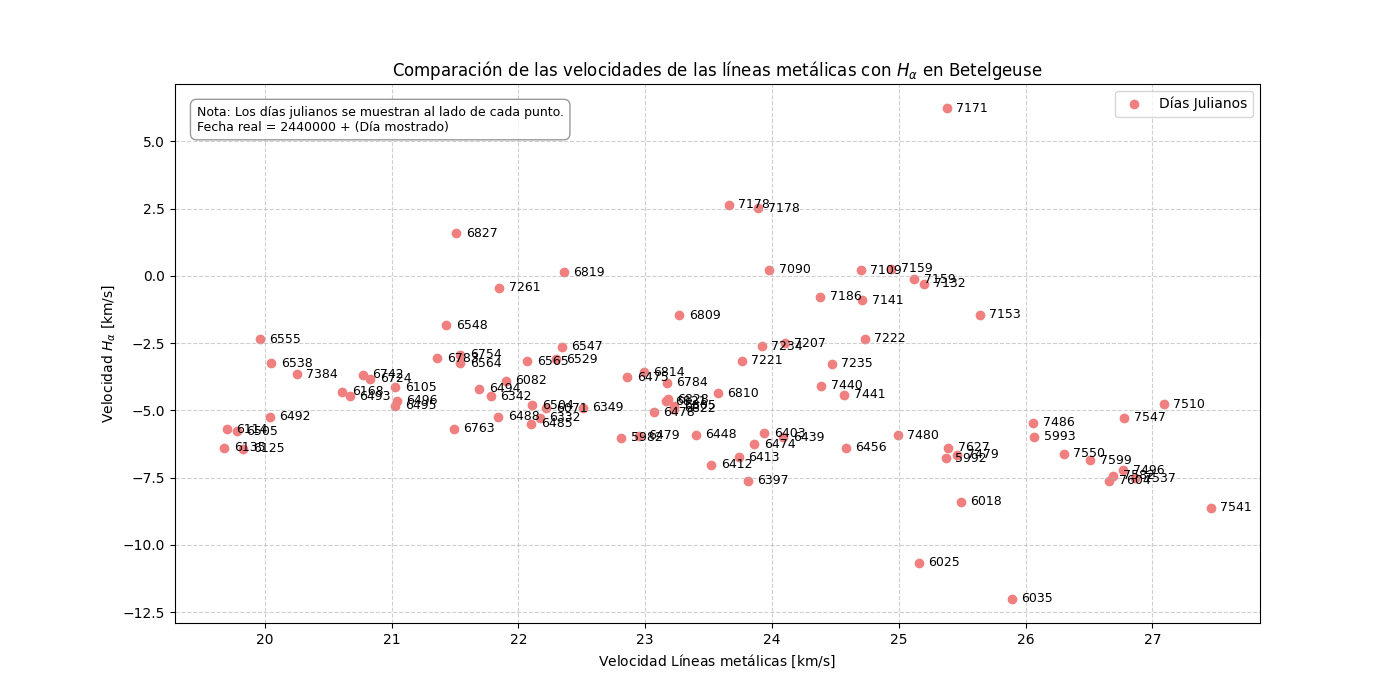

In [143]:
plt.close('all')  # Cierra todas las figuras abiertas previamente
plt.figure(figsize=(14, 7))
plt.scatter(velocidad_metales_betelgeuse, velocidad_hidrogeno_betelgeuse, color = "lightcoral")

#Reconocer a que día hace referencia cada punto en el gráfico
for dia, v_metal, v_hidrogeno in zip(dias_julianos_betelgeuse, velocidad_metales_betelgeuse, velocidad_hidrogeno_betelgeuse):
    plt.text(
        v_metal + 0.075,     
        v_hidrogeno,       
        str(dia),          
        fontsize=9,        
        va='center'       
    )

plt.xlabel(r"Velocidad Líneas metálicas [$\mathrm{km/s}$]")
plt.ylabel(r"Velocidad $H_\alpha$ [$\mathrm{km/s}$]")
plt.title(r"Comparación de las velocidades de las líneas metálicas con $H_\alpha$ en Betelgeuse")

ax = plt.gca()  #Mantiene el mismo eje de la gráfica

texto_nota = (
    "Nota: Los días julianos se muestran al lado de cada punto.\n"
    "Fecha real = 2440000 + (Día mostrado)"
)
ax.text(
    0.02, 0.96, texto_nota,  # 0.02 = casi al borde izquierdo, 0.98 = casi arriba
    transform=ax.transAxes,  # Coordenadas en fracción del eje (0 a 1)
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)
plt.legend(["Días Julianos"], loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

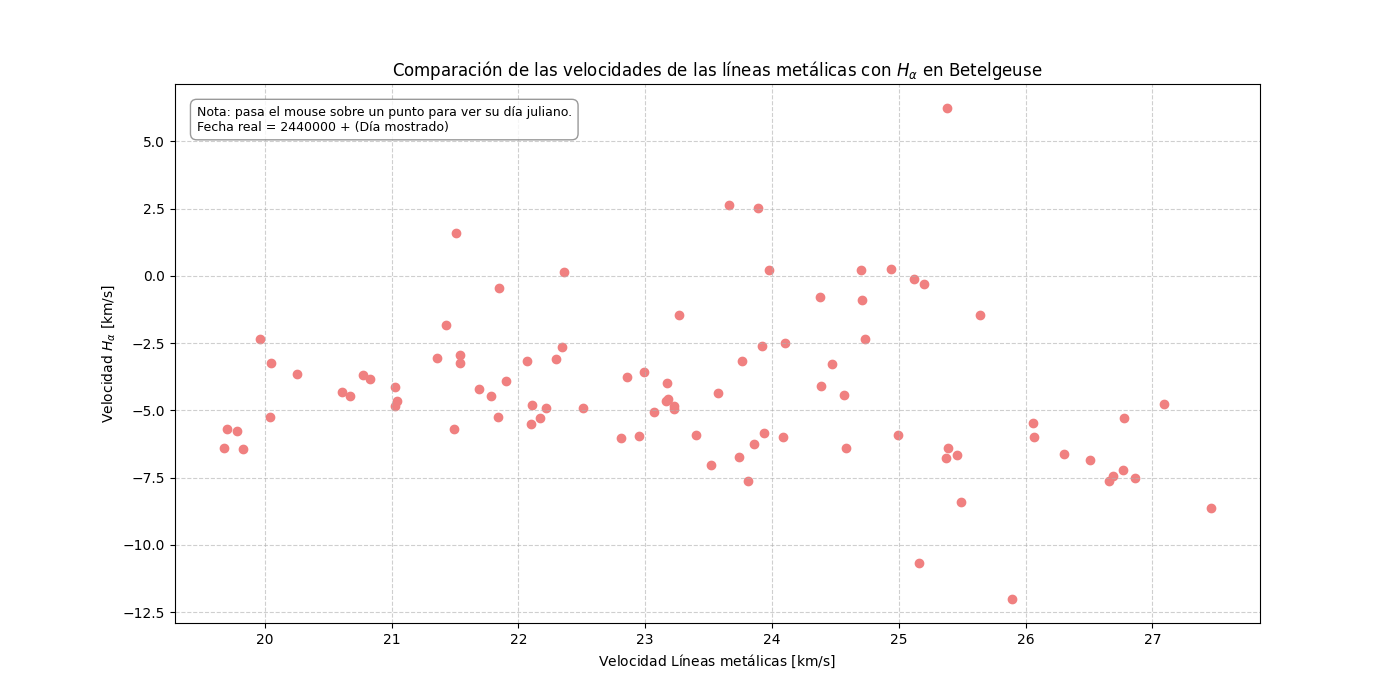

In [144]:
%matplotlib widget
import matplotlib.pyplot as plt
import mplcursors

plt.figure(figsize=(14, 7))
sc = plt.scatter(velocidad_metales_betelgeuse, velocidad_hidrogeno_betelgeuse, color="lightcoral")

plt.xlabel(r"Velocidad Líneas metálicas [$\mathrm{km/s}$]")
plt.ylabel(r"Velocidad $H_\alpha$ [$\mathrm{km/s}$]")
plt.title(r"Comparación de las velocidades de las líneas metálicas con $H_\alpha$ en Betelgeuse")

ax = plt.gca()

texto_nota = (
    "Nota: pasa el mouse sobre un punto para ver su día juliano.\n"
    "Fecha real = 2440000 + (Día mostrado)"
)
ax.text(
    0.02, 0.96, texto_nota,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.grid(True, linestyle='--', alpha=0.6)

# Cursor interactivo
cursor = mplcursors.cursor(sc, hover=True)

@cursor.connect("add")
def mostrar_dia(sel):
    i = sel.index  # índice del punto sobre el que está el mouse
    dia = dias_julianos_betelgeuse[i]
    sel.annotation.set_text(f"Día: {dia}\nFecha real: {2440000 + dia}")

plt.show()

Gráficas de las velocidades radiales de las líneas metálicas con las velocidades relativas de la línea $H_\alpha$ por año

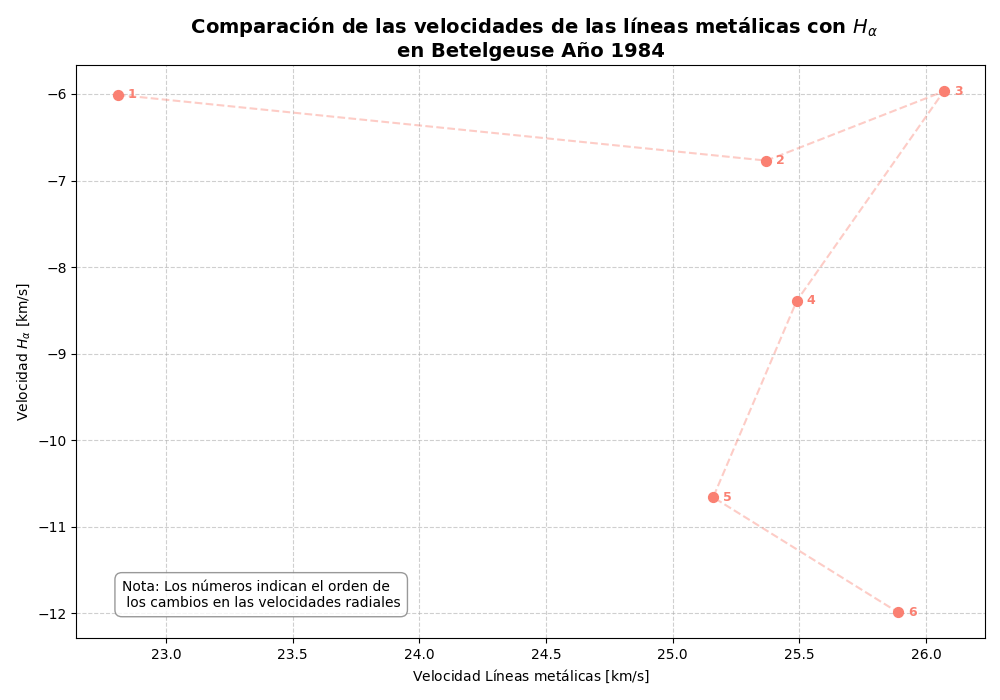

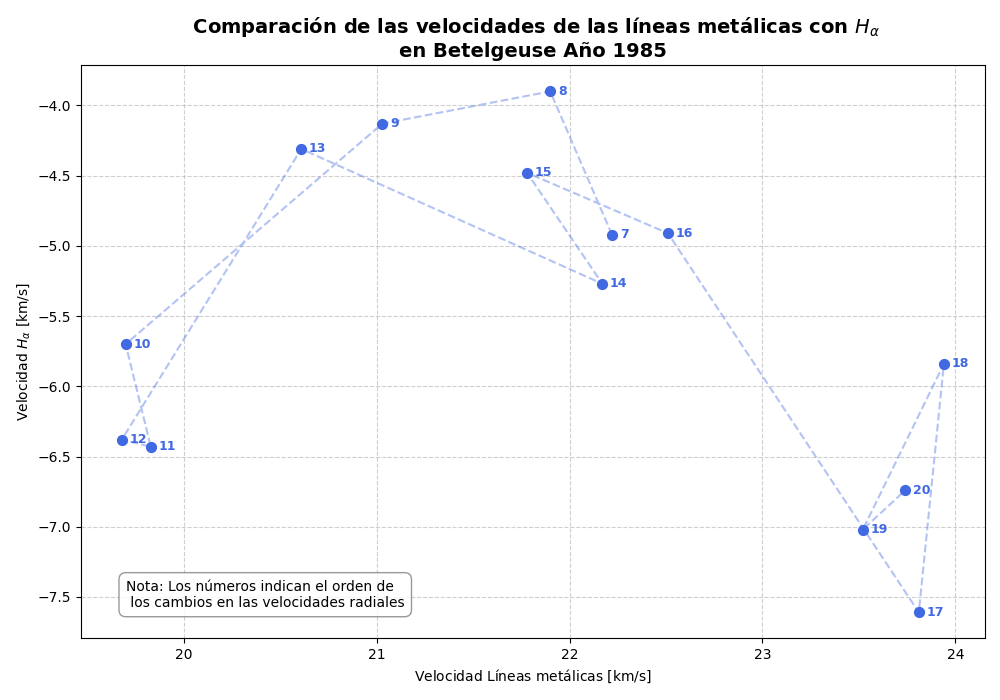

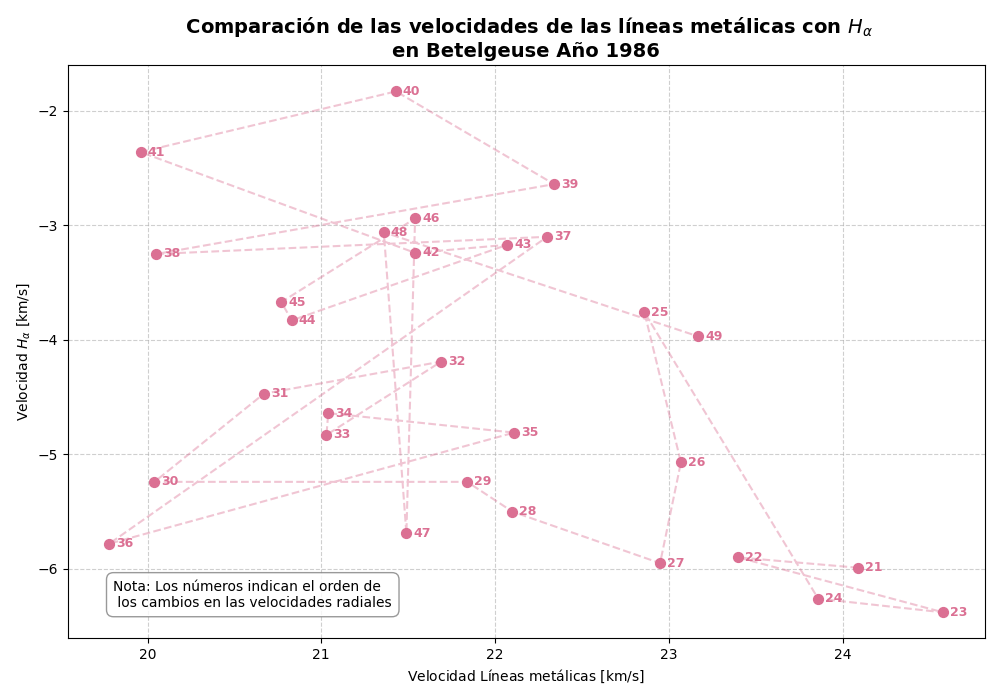

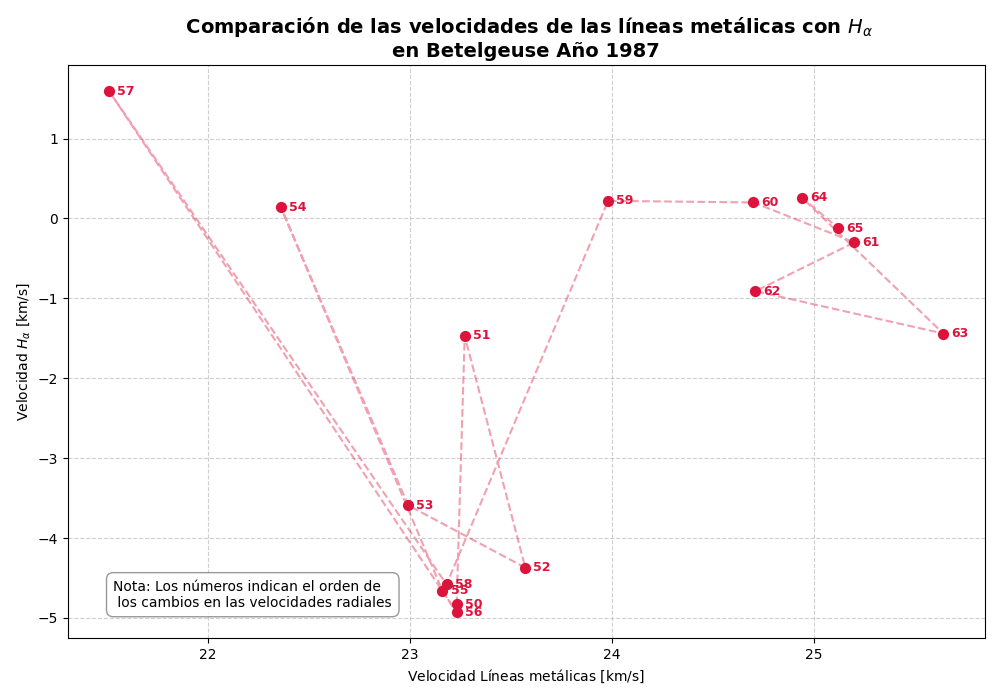

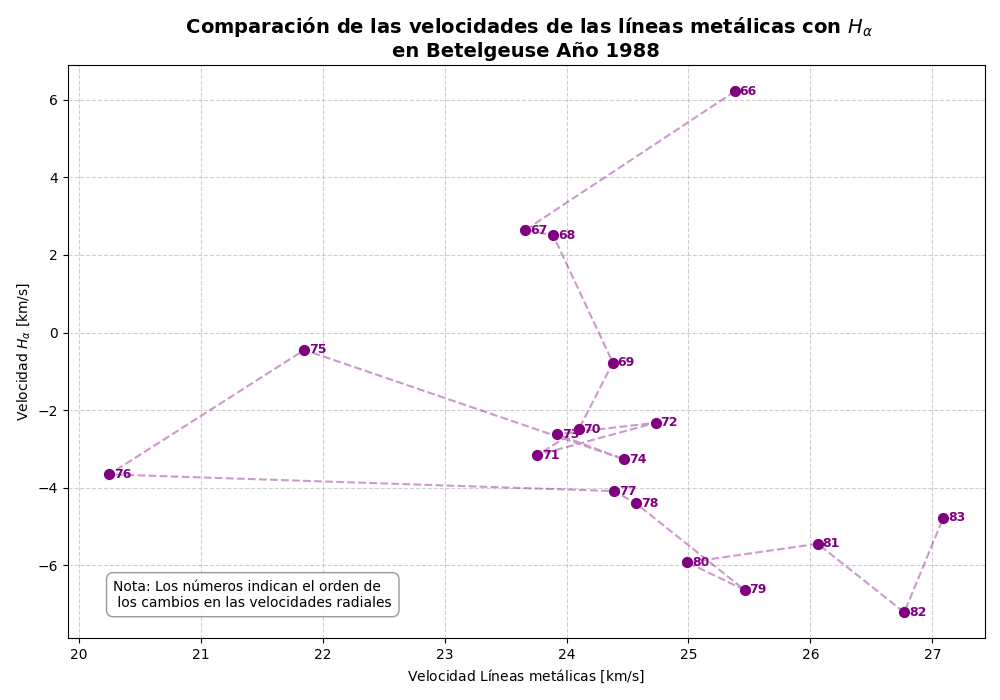

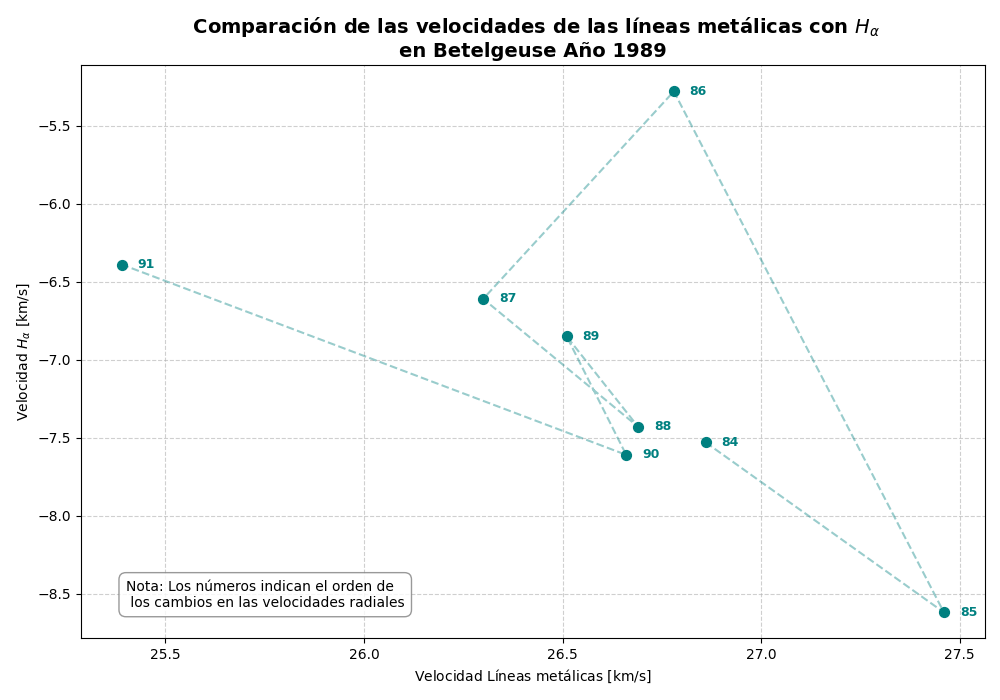

In [145]:

# Obtención de año
dias_julianos_b_reales = 2440000 + dias_julianos_betelgeuse
observaciones_b = Time(dias_julianos_b_reales, format='jd')
anios_b = [t.year for t in observaciones_b.to_datetime()]

# Creación de DataFrame para obtener los índices de los datos
df_betelgeuse = pd.DataFrame({
    'indice_original': range(1, len(dias_julianos_betelgeuse) + 1), 
    'dia_juliano_original': dias_julianos_betelgeuse,
    'v_metal': velocidad_metales_betelgeuse,
    'v_hidrogeno': velocidad_hidrogeno_betelgeuse,
    'anio': anios_b
})

# Colores para cada año
colores = ['salmon', 'royalblue', 'palevioletred', 'crimson', 'purple', 'teal']
anios_unicos = sorted(df_betelgeuse['anio'].unique())

# Creación de gráficas por año
for i, anio_actual in enumerate(anios_unicos):
    df_anio = df_betelgeuse[df_betelgeuse['anio'] == anio_actual]
    
    plt.figure(figsize=(10, 7))
    
  
    color_actual = colores[i % len(colores)]
    
    
    plt.scatter(df_anio['v_metal'], df_anio['v_hidrogeno'], color=color_actual, s=50, zorder=3)

    plt.plot(df_anio['v_metal'], df_anio['v_hidrogeno'], color=color_actual, linestyle='--', alpha=0.4, zorder=2)

    
    for _, row in df_anio.iterrows():
        plt.text(
            row['v_metal'] + 0.04,  
            row['v_hidrogeno'],     
            str(int(row['indice_original'])),  
            fontsize=9,
            fontweight='bold',
            va='center',
            color=color_actual
        )

    plt.xlabel(r"Velocidad Líneas metálicas [$\mathrm{km/s}$]")
    plt.ylabel(r"Velocidad $H_\alpha$ [$\mathrm{km/s}$]")
    plt.title(r" Comparación de las velocidades de las líneas metálicas con $H_\alpha$" + "\n" + r"en Betelgeuse Año %d" % anio_actual, fontsize=14, fontweight='bold')

    ax = plt.gca()

    texto_nota = (
        "Nota: Los números indican el orden de \n los cambios en las velocidades radiales"
    )
    ax.text(
        0.05, 0.05, texto_nota,
        transform=ax.transAxes,
        fontsize=10,
        horizontalalignment='left',
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    )
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Antares

Ras Algethi

In [146]:
dias_julianos_rasalgethi = datos_rasalgethi['Día Juliano.2'].values
velocidad_metales_rasalgethi = datos_rasalgethi['Líneas Metálicas.2'].values
velocidad_hidrogeno_rasalgethi = datos_rasalgethi['H_alpha.2'].values

In [147]:
for i, dia in enumerate(dias_julianos_rasalgethi):
    if pd.isna(dia):
        print(f"Falta el día juliano en la posición {i}")

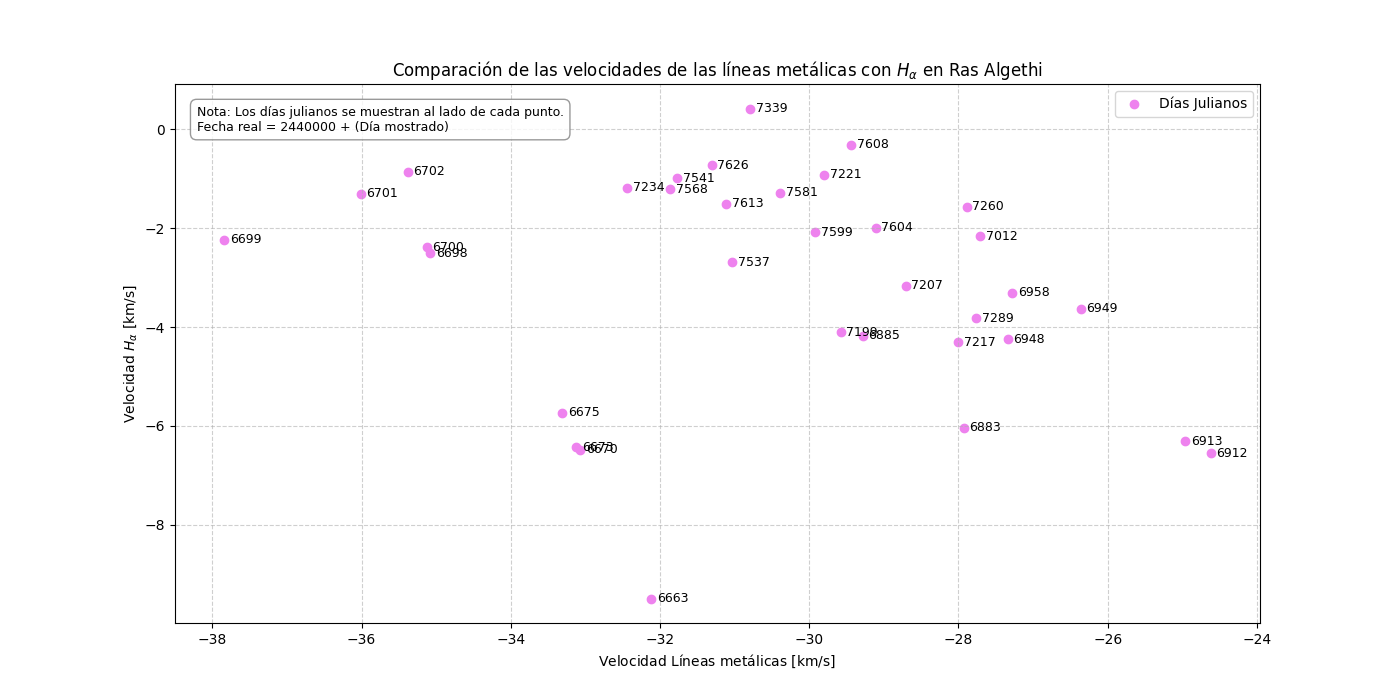

In [148]:
plt.figure(figsize=(14, 7))
plt.scatter(velocidad_metales_rasalgethi, velocidad_hidrogeno_rasalgethi, color = "violet")

#Reconocer a que día hace referencia cada punto en el gráfico
for dia_2, v_metal_2, v_hidrogeno_2 in zip(dias_julianos_rasalgethi, velocidad_metales_rasalgethi, velocidad_hidrogeno_rasalgethi):
    plt.text(
        v_metal_2 + 0.075,     
        v_hidrogeno_2,       
        str(int(dia_2)),          
        fontsize=9,        
        va='center'       
    )

plt.xlabel(r"Velocidad Líneas metálicas [$\mathrm{km/s}$]")
plt.ylabel(r"Velocidad $H_\alpha$ [$\mathrm{km/s}$]")
plt.title(r"Comparación de las velocidades de las líneas metálicas con $H_\alpha$ en Ras Algethi")

ax = plt.gca()  #Mantiene el mismo eje de la gráfica

texto_nota = (
    "Nota: Los días julianos se muestran al lado de cada punto.\n"
    "Fecha real = 2440000 + (Día mostrado)"
)
ax.text(
    0.02, 0.96, texto_nota,  # 0.02 = casi al borde izquierdo, 0.98 = casi arriba
    transform=ax.transAxes,  # Coordenadas en fracción del eje (0 a 1)
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)
plt.legend(["Días Julianos"], loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

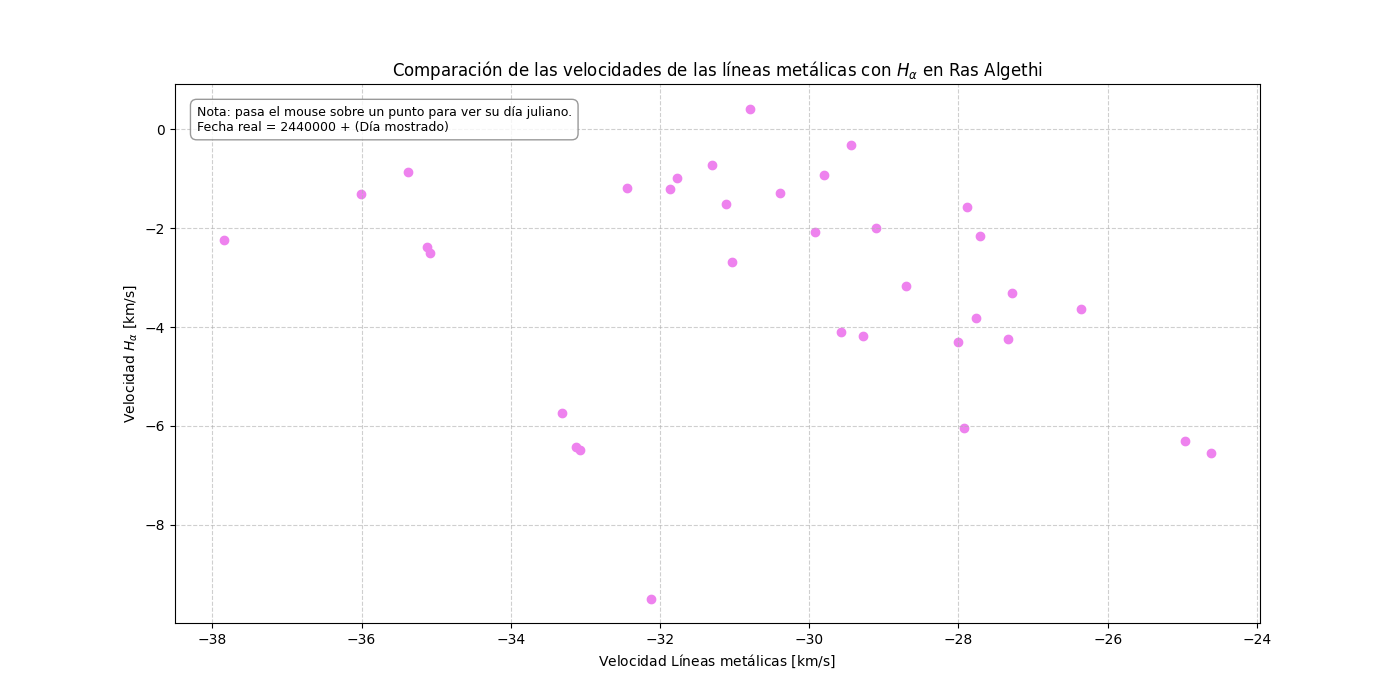

In [149]:
%matplotlib widget
import matplotlib.pyplot as plt
import mplcursors

plt.figure(figsize=(14, 7))
sc = plt.scatter(velocidad_metales_rasalgethi, velocidad_hidrogeno_rasalgethi, color="violet")

plt.xlabel(r"Velocidad Líneas metálicas [$\mathrm{km/s}$]")
plt.ylabel(r"Velocidad $H_\alpha$ [$\mathrm{km/s}$]")
plt.title(r"Comparación de las velocidades de las líneas metálicas con $H_\alpha$ en Ras Algethi")

ax = plt.gca()

texto_nota = (
    "Nota: pasa el mouse sobre un punto para ver su día juliano.\n"
    "Fecha real = 2440000 + (Día mostrado)"
)
ax.text(
    0.02, 0.96, texto_nota,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.grid(True, linestyle='--', alpha=0.6)

# Aquí está la magia: conecta el cursor interactivo al scatter
cursor = mplcursors.cursor(sc, hover=True)

@cursor.connect("add")
def mostrar_dia(sel):
    i = sel.index  # índice del punto sobre el que está el mouse
    dia = dias_julianos_rasalgethi[i]
    dia = int(dia)
    sel.annotation.set_text(f"Día: {dia}\nFecha real: {2440000 + dia}")

plt.show()